# import libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             roc_auc_score, roc_curve, auc, confusion_matrix, 
                             precision_recall_curve, average_precision_score, 
                             classification_report)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

# PATH CONFIGURATION

In [6]:
# ====================== PATH CONFIGURATION ======================
CANCER_PATH = r"C:\Users\FAHAD\Downloads\archive (4)\data.csv"
HEART_PATH = r"C:\Users\FAHAD\Downloads\heart+disease\heart.csv"

print("✅ Cancer file exists:", os.path.exists(CANCER_PATH))
print("✅ Heart file exists :", os.path.exists(HEART_PATH))

if not os.path.exists(CANCER_PATH):
    print("Please check cancer file path!")
if not os.path.exists(HEART_PATH):
    print("Please check heart file path!")

✅ Cancer file exists: True
✅ Heart file exists : False
Please check heart file path!


In [7]:
import os

# ====================== PATH CONFIGURATION ======================
CANCER_PATH = r"C:\Users\FAHAD\Downloads\archive (4)\data.csv"
HEART_PATH = r"C:\Users\FAHAD\Downloads\heart+disease\cleveland.data"

print("✅ Cancer file exists:", os.path.exists(CANCER_PATH))
print("✅ Heart file exists :", os.path.exists(HEART_PATH))

✅ Cancer file exists: True
✅ Heart file exists : True


# BREAST CANCER DATASET

In [8]:
# ====================== BREAST CANCER DATASET ======================
print("="*60)
print("BREAST CANCER DATASET")
print("="*60)

df_cancer = pd.read_csv(CANCER_PATH)
print("Shape:", df_cancer.shape)
print("\nColumns:", df_cancer.columns.tolist())

# Preprocessing
if 'id' in df_cancer.columns:
    df_cancer = df_cancer.drop(columns=['id'])
    
df_cancer['diagnosis'] = df_cancer['diagnosis'].map({'M': 1, 'B': 0})

X_cancer = df_cancer.drop(columns=['diagnosis'])
y_cancer = df_cancer['diagnosis']

print("\nClass Distribution:\n", y_cancer.value_counts())
df_cancer.head()

BREAST CANCER DATASET
Shape: (569, 33)

Columns: ['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']

Class Distribution:
 diagnosis
0    357
1    212
Name: count, dtype: int64


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


# Missing Values

In [11]:
df_temp = pd.read_csv(CANCER_PATH)
print("Total Missing Values:", df_temp.isnull().sum().sum())
print("\nColumns with NaN:")
print(df_temp.isnull().sum()[df_temp.isnull().sum() > 0])

Total Missing Values: 569

Columns with NaN:
Unnamed: 32    569
dtype: int64


In [12]:
# ====================== BREAST CANCER DATASET ======================
print("="*60)
print("BREAST CANCER DATASET")
print("="*60)

df_cancer = pd.read_csv(CANCER_PATH)
print("Original Shape:", df_cancer.shape)

# Drop 'id' if exists
if 'id' in df_cancer.columns:
    df_cancer = df_cancer.drop(columns=['id'])

# === FIX: Drop the empty Unnamed column ===
if 'Unnamed: 32' in df_cancer.columns:
    df_cancer = df_cancer.drop(columns=['Unnamed: 32'])
    print("✅ Dropped 'Unnamed: 32' column")

# Convert diagnosis to numeric
df_cancer['diagnosis'] = df_cancer['diagnosis'].map({'M': 1, 'B': 0})

print("Missing Values After Cleaning:", df_cancer.isnull().sum().sum())
print("Final Shape:", df_cancer.shape)

X_cancer = df_cancer.drop(columns=['diagnosis'])
y_cancer = df_cancer['diagnosis']

print("\nClass Distribution:\n", y_cancer.value_counts())
df_cancer.head()

BREAST CANCER DATASET
Original Shape: (569, 33)
✅ Dropped 'Unnamed: 32' column
Missing Values After Cleaning: 0
Final Shape: (569, 31)

Class Distribution:
 diagnosis
0    357
1    212
Name: count, dtype: int64


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# MODEL TRAINING

In [15]:
# ====================== MODEL TRAINING - BREAST CANCER ======================

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cancer, y_cancer, test_size=0.2, random_state=42, stratify=y_cancer
)

model_cancer = GradientBoostingClassifier(
    learning_rate=0.2,
    n_estimators=300,
    max_depth=5,
    random_state=42
)

model_cancer.fit(X_train_c, y_train_c)
y_pred_c = model_cancer.predict(X_test_c)
y_prob_c = model_cancer.predict_proba(X_test_c)[:, 1]

print("=== Breast Cancer Model Performance ===")
print(f"Accuracy  : {accuracy_score(y_test_c, y_pred_c):.4f}")
print(f"Precision : {precision_score(y_test_c, y_pred_c):.4f}")
print(f"Recall    : {recall_score(y_test_c, y_pred_c):.4f}")
print(f"F1 Score  : {f1_score(y_test_c, y_pred_c):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test_c, y_prob_c):.4f}")

print("\nClassification Report:")
print(classification_report(y_test_c, y_pred_c))

=== Breast Cancer Model Performance ===
Accuracy  : 0.9298
Precision : 0.9250
Recall    : 0.8810
F1 Score  : 0.9024
ROC-AUC   : 0.9878

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.96      0.95        72
           1       0.93      0.88      0.90        42

    accuracy                           0.93       114
   macro avg       0.93      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



In [14]:
df_cancer = pd.read_csv(CANCER_PATH)
df_cancer = df_cancer.drop(columns=['id', 'Unnamed: 32'], errors='ignore')
df_cancer['diagnosis'] = df_cancer['diagnosis'].map({'M': 1, 'B': 0})

# VISUALIZATIONS

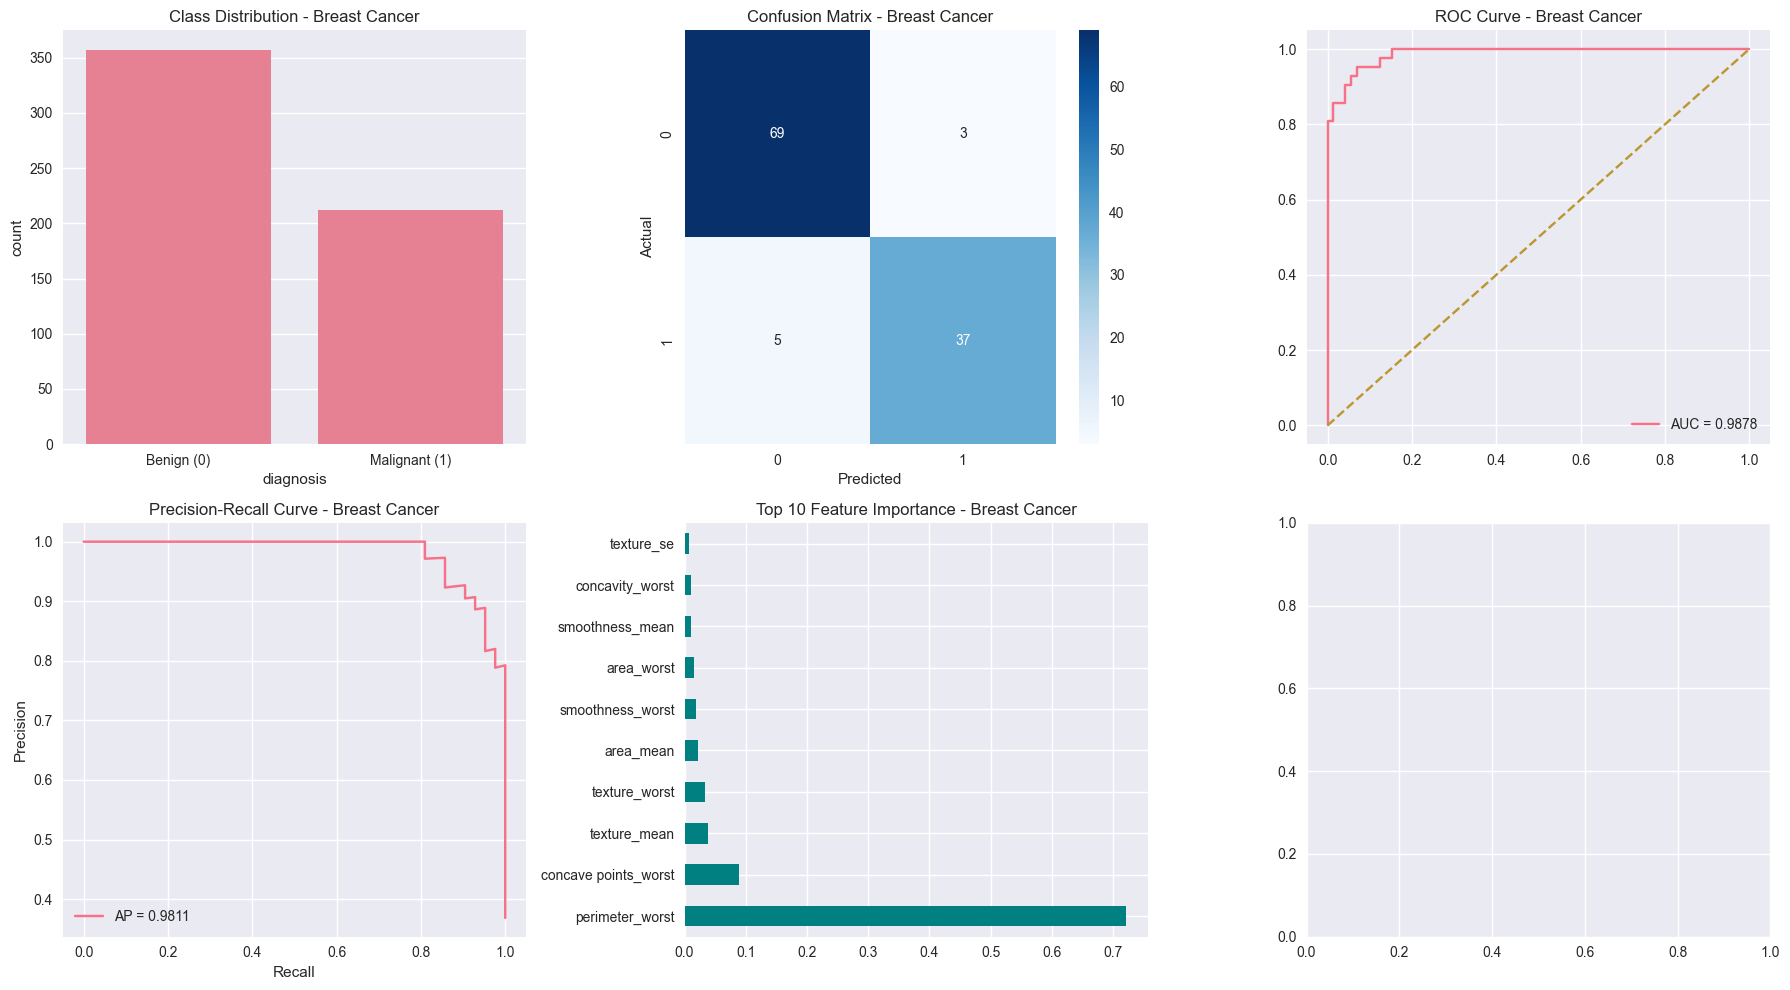

In [31]:
# ====================== VISUALIZATIONS - BREAST CANCER ======================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Class Distribution
sns.countplot(x=y_cancer, ax=axes[0,0])
axes[0,0].set_title("Class Distribution - Breast Cancer")
axes[0,0].set_xticklabels(['Benign (0)', 'Malignant (1)'])

# 2. Confusion Matrix
cm_c = confusion_matrix(y_test_c, y_pred_c)
sns.heatmap(cm_c, annot=True, fmt='d', cmap='Blues', ax=axes[0,1])
axes[0,1].set_title('Confusion Matrix - Breast Cancer')
axes[0,1].set_xlabel('Predicted')
axes[0,1].set_ylabel('Actual')

# 3. ROC Curve
fpr_c, tpr_c, _ = roc_curve(y_test_c, y_prob_c)
axes[0,2].plot(fpr_c, tpr_c, label=f'AUC = {auc(fpr_c, tpr_c):.4f}')
axes[0,2].plot([0,1],[0,1],'--')
axes[0,2].set_title('ROC Curve - Breast Cancer')
axes[0,2].legend()

# 4. Precision-Recall Curve
prec_c, rec_c, _ = precision_recall_curve(y_test_c, y_prob_c)
axes[1,0].plot(rec_c, prec_c, label=f'AP = {average_precision_score(y_test_c, y_prob_c):.4f}')
axes[1,0].set_title('Precision-Recall Curve - Breast Cancer')
axes[1,0].set_xlabel('Recall')
axes[1,0].set_ylabel('Precision')
axes[1,0].legend()

# 5. Top 10 Feature Importance
feat_imp_c = pd.Series(model_cancer.feature_importances_, index=X_cancer.columns)
feat_imp_c.nlargest(10).plot(kind='barh', ax=axes[1,1], color='teal')
axes[1,1].set_title("Top 10 Feature Importance - Breast Cancer")

plt.tight_layout()
plt.show()

# HYPERPARAMETER TUNING

In [16]:
# ====================== HYPERPARAMETER TUNING - BREAST CANCER ======================
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
import time

print("="*70)
print("HYPERPARAMETER TUNING FOR BREAST CANCER DATASET")
print("="*70)

# Parameter grid for Gradient Boosting
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [3, 4, 5, 6, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'max_features': ['sqrt', 'log2', None]
}

HYPERPARAMETER TUNING FOR BREAST CANCER DATASET


In [17]:
# RandomizedSearchCV (Best balance of speed and performance)
start_time = time.time()

random_search = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=60,                    # Try 60 random combinations
    cv=5,                         # 5-fold cross validation
    scoring='roc_auc',            # Optimize for ROC-AUC
    n_jobs=-1,                    # Use all CPU cores
    random_state=42,
    verbose=2
)

random_search.fit(X_train_c, y_train_c)

print(f"\n✅ Tuning Completed in {time.time() - start_time:.1f} seconds")
print("Best Parameters Found:", random_search.best_params_)
print("Best Cross-Validation ROC-AUC:", round(random_search.best_score_, 4))

# Save best model
best_model_cancer = random_search.best_estimator_

Fitting 5 folds for each of 60 candidates, totalling 300 fits

✅ Tuning Completed in 78.1 seconds
Best Parameters Found: {'subsample': 0.9, 'n_estimators': 400, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 7, 'learning_rate': 0.1}
Best Cross-Validation ROC-AUC: 0.9942


# EVALUATION OF TUNED MODEL

In [18]:
# ====================== EVALUATION OF TUNED MODEL ======================

y_pred_tuned = best_model_cancer.predict(X_test_c)
y_prob_tuned = best_model_cancer.predict_proba(X_test_c)[:, 1]

print("=== TUNED MODEL PERFORMANCE (Breast Cancer) ===")
print(f"Accuracy  : {accuracy_score(y_test_c, y_pred_tuned):.4f}")
print(f"Precision : {precision_score(y_test_c, y_pred_tuned):.4f}")
print(f"Recall    : {recall_score(y_test_c, y_pred_tuned):.4f}")
print(f"F1 Score  : {f1_score(y_test_c, y_pred_tuned):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test_c, y_prob_tuned):.4f}")

print("\nClassification Report:")
print(classification_report(y_test_c, y_pred_tuned))

=== TUNED MODEL PERFORMANCE (Breast Cancer) ===
Accuracy  : 0.9649
Precision : 1.0000
Recall    : 0.9048
F1 Score  : 0.9500
ROC-AUC   : 0.9987

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        72
           1       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



# Comparison Table

In [19]:
# Comparison Table
comparison_tuning = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Default Model": [
        accuracy_score(y_test_c, y_pred_c),
        precision_score(y_test_c, y_pred_c),
        recall_score(y_test_c, y_pred_c),
        f1_score(y_test_c, y_pred_c),
        roc_auc_score(y_test_c, y_prob_c)
    ],
    "Tuned Model": [
        accuracy_score(y_test_c, y_pred_tuned),
        precision_score(y_test_c, y_pred_tuned),
        recall_score(y_test_c, y_pred_tuned),
        f1_score(y_test_c, y_pred_tuned),
        roc_auc_score(y_test_c, y_prob_tuned)
    ]
}

df_tuning = pd.DataFrame(comparison_tuning).round(4)
df_tuning

,Metric,Default Model,Tuned Model
0,Accuracy,0.9298,0.9649
1,Precision,0.9250,1.0000
2,Recall,0.8810,0.9048
3,F1 Score,0.9024,0.9500
4,ROC-AUC,0.9878,0.9987


# Visual Comparison

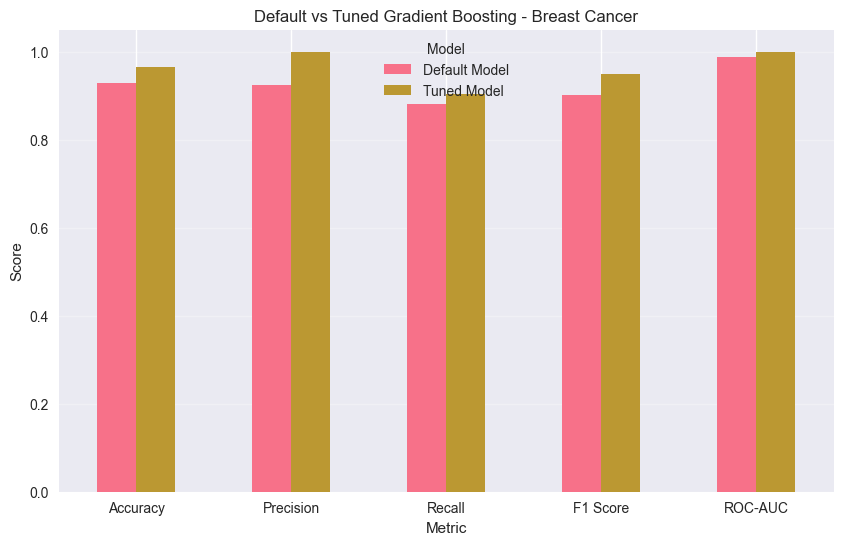

In [20]:
# Visual Comparison
df_tuning.set_index("Metric").plot(kind='bar', figsize=(10, 6))
plt.title("Default vs Tuned Gradient Boosting - Breast Cancer")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.grid(axis='y', alpha=0.3)
plt.show()

# Heart Disease - Loading & Preprocessing

In [22]:
# ====================== HEART DISEASE DATASET ======================
print("="*60)
print("HEART DISEASE DATASET")
print("="*60)

# Use the processed version if available, otherwise load raw cleveland.data correctly
HEART_PATH = r"C:\Users\FAHAD\Downloads\heart+disease\processed.cleveland.data"

# Try processed file first (recommended)
if os.path.exists(HEART_PATH):
    print("Loading processed.cleveland.data")
    df_heart = pd.read_csv(HEART_PATH, header=None, sep=",", na_values='?')
else:
    # Fallback to raw cleveland.data with proper settings
    HEART_PATH = r"C:\Users\FAHAD\Downloads\heart+disease\cleveland.data"
    print("Loading raw cleveland.data")
    df_heart = pd.read_csv(HEART_PATH, header=None, sep=r'\s+', na_values='?', encoding='latin1')

# Column names for UCI Heart Disease dataset
column_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 
                'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

df_heart.columns = column_names

# Clean target: Usually 0 = No disease, 1-4 = Disease → convert to binary
df_heart['target'] = df_heart['target'].map(lambda x: 1 if x > 0 else 0)

print("Shape:", df_heart.shape)
print("Class Distribution:\n", df_heart['target'].value_counts())
print("Missing Values:", df_heart.isnull().sum().sum())

df_heart.head()

HEART DISEASE DATASET
Loading processed.cleveland.data
Shape: (303, 14)
Class Distribution:
 target
0    164
1    139
Name: count, dtype: int64
Missing Values: 6


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


# Handle Missing Values

In [23]:
# Handle missing values
print("Missing values before:", df_heart.isnull().sum().sum())

# Fill numerical missing values with median
df_heart = df_heart.fillna(df_heart.median(numeric_only=True))

print("Missing values after:", df_heart.isnull().sum().sum())

Missing values before: 6
Missing values after: 0


In [24]:
X_heart = df_heart.drop(columns=['target'])
y_heart = df_heart['target']

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_heart, y_heart, test_size=0.2, random_state=42, stratify=y_heart
)

print("Training shape:", X_train_h.shape)
print("Testing shape :", X_test_h.shape)

Training shape: (242, 13)
Testing shape : (61, 13)


# Train-Test Split & Default Model

In [25]:
# ====================== TRAIN-TEST SPLIT & DEFAULT MODEL ======================
X_heart = df_heart.drop(columns=['target'])
y_heart = df_heart['target']

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_heart, y_heart, test_size=0.2, random_state=42, stratify=y_heart
)

print("Training set:", X_train_h.shape)
print("Testing set :", X_test_h.shape)

# Default Model
model_heart = GradientBoostingClassifier(
    learning_rate=0.2,
    n_estimators=300,
    max_depth=5,
    random_state=42
)

model_heart.fit(X_train_h, y_train_h)
y_pred_h = model_heart.predict(X_test_h)
y_prob_h = model_heart.predict_proba(X_test_h)[:, 1]

print("\n=== Default Model Performance (Heart Disease) ===")
print(f"Accuracy  : {accuracy_score(y_test_h, y_pred_h):.4f}")
print(f"Precision : {precision_score(y_test_h, y_pred_h):.4f}")
print(f"Recall    : {recall_score(y_test_h, y_pred_h):.4f}")
print(f"F1 Score  : {f1_score(y_test_h, y_pred_h):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test_h, y_prob_h):.4f}")

Training set: (242, 13)
Testing set : (61, 13)

=== Default Model Performance (Heart Disease) ===
Accuracy  : 0.8361
Precision : 0.7500
Recall    : 0.9643
F1 Score  : 0.8438
ROC-AUC   : 0.9361


# Heart Disease Visualizations

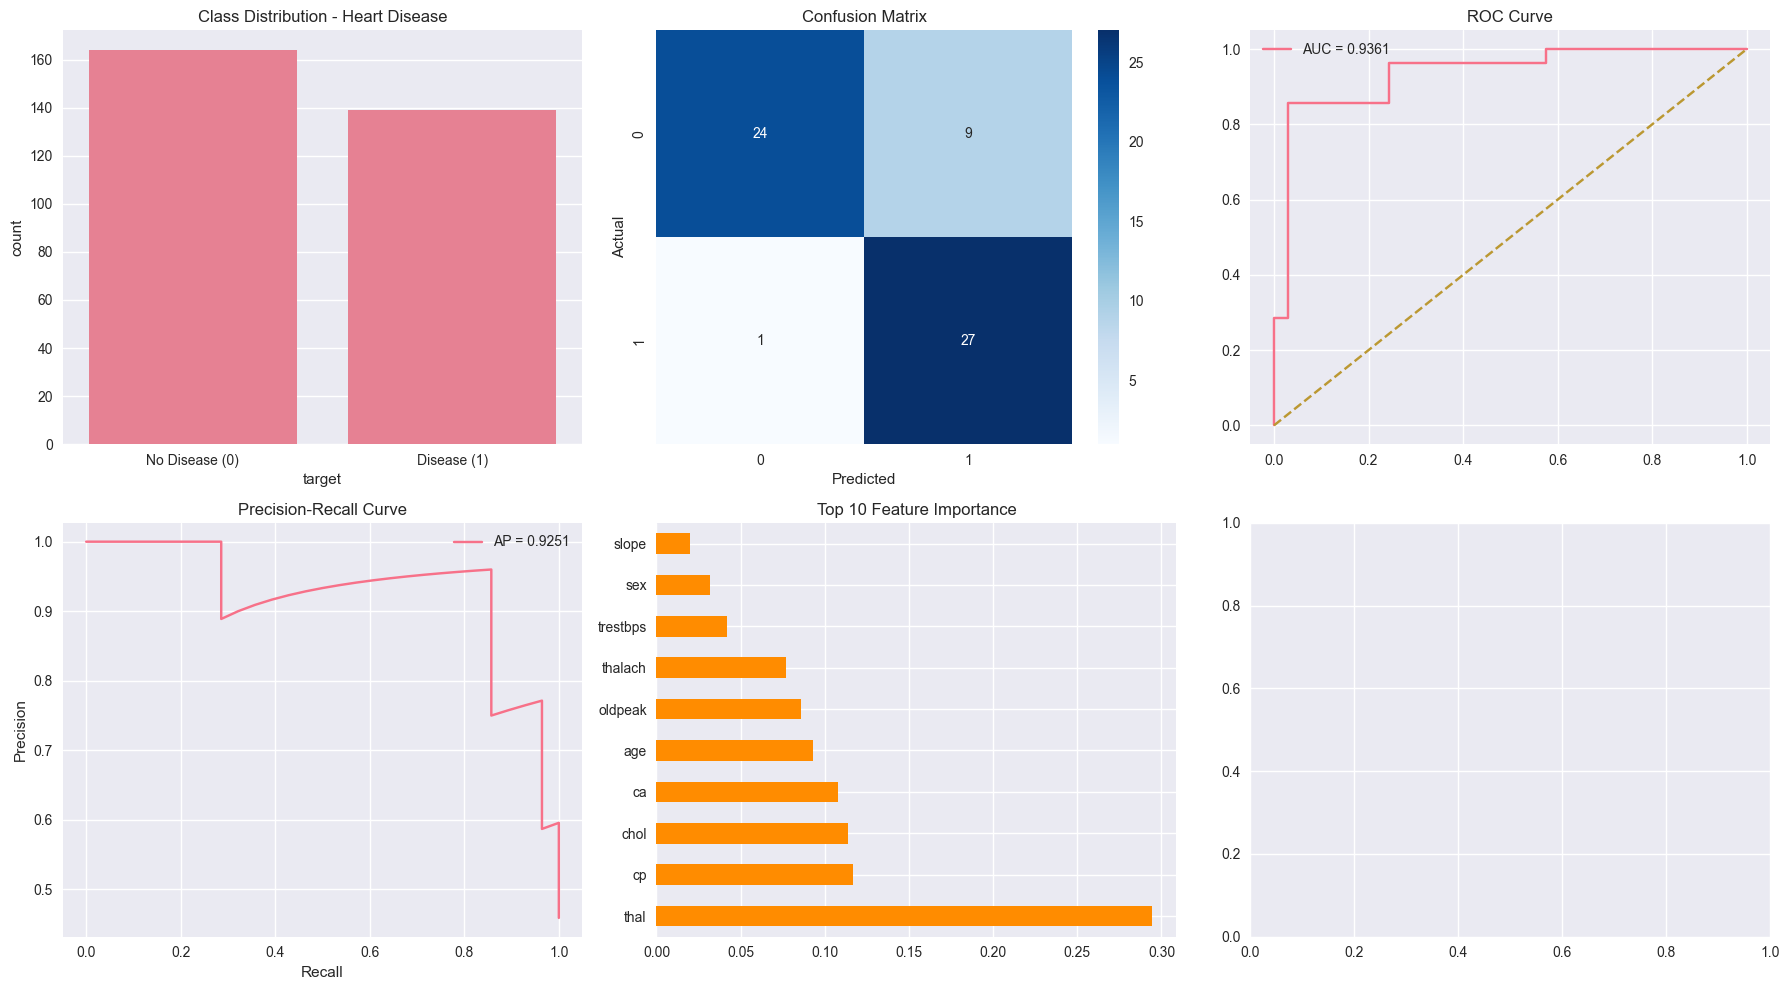

In [26]:
# ====================== VISUALIZATIONS - HEART DISEASE ======================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Class Distribution
sns.countplot(x=y_heart, ax=axes[0,0])
axes[0,0].set_title("Class Distribution - Heart Disease")
axes[0,0].set_xticklabels(['No Disease (0)', 'Disease (1)'])

# 2. Confusion Matrix
cm_h = confusion_matrix(y_test_h, y_pred_h)
sns.heatmap(cm_h, annot=True, fmt='d', cmap='Blues', ax=axes[0,1])
axes[0,1].set_title('Confusion Matrix')
axes[0,1].set_xlabel('Predicted')
axes[0,1].set_ylabel('Actual')

# 3. ROC Curve
fpr_h, tpr_h, _ = roc_curve(y_test_h, y_prob_h)
axes[0,2].plot(fpr_h, tpr_h, label=f'AUC = {auc(fpr_h, tpr_h):.4f}')
axes[0,2].plot([0,1],[0,1],'--')
axes[0,2].set_title('ROC Curve')
axes[0,2].legend()

# 4. Precision-Recall
prec_h, rec_h, _ = precision_recall_curve(y_test_h, y_prob_h)
axes[1,0].plot(rec_h, prec_h, label=f'AP = {average_precision_score(y_test_h, y_prob_h):.4f}')
axes[1,0].set_title('Precision-Recall Curve')
axes[1,0].set_xlabel('Recall')
axes[1,0].set_ylabel('Precision')
axes[1,0].legend()

# 5. Top 10 Feature Importance
feat_imp_h = pd.Series(model_heart.feature_importances_, index=X_heart.columns)
feat_imp_h.nlargest(10).plot(kind='barh', ax=axes[1,1], color='darkorange')
axes[1,1].set_title("Top 10 Feature Importance")

plt.tight_layout()
plt.show()

# Hyperparameter Tuning - Heart Disease

In [27]:
# ====================== HYPERPARAMETER TUNING - HEART DISEASE ======================
from sklearn.model_selection import RandomizedSearchCV
import time

print("="*70)
print("HYPERPARAMETER TUNING - HEART DISEASE")
print("="*70)

param_grid = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [3, 4, 5, 6, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'max_features': ['sqrt', 'log2', None]
}

start_time = time.time()

random_search_h = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=60,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=2
)

random_search_h.fit(X_train_h, y_train_h)

print(f"\n✅ Tuning Completed in {time.time() - start_time:.1f} seconds")
print("Best Parameters:", random_search_h.best_params_)
print("Best CV ROC-AUC:", round(random_search_h.best_score_, 4))

best_model_heart = random_search_h.best_estimator_

HYPERPARAMETER TUNING - HEART DISEASE
Fitting 5 folds for each of 60 candidates, totalling 300 fits

✅ Tuning Completed in 43.0 seconds
Best Parameters: {'subsample': 0.7, 'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 4, 'learning_rate': 0.01}
Best CV ROC-AUC: 0.8902


# Tuned Model Evaluation

In [28]:
# ====================== TUNED MODEL EVALUATION ======================
y_pred_tuned_h = best_model_heart.predict(X_test_h)
y_prob_tuned_h = best_model_heart.predict_proba(X_test_h)[:, 1]

print("=== TUNED MODEL PERFORMANCE (Heart Disease) ===")
print(f"Accuracy  : {accuracy_score(y_test_h, y_pred_tuned_h):.4f}")
print(f"Precision : {precision_score(y_test_h, y_pred_tuned_h):.4f}")
print(f"Recall    : {recall_score(y_test_h, y_pred_tuned_h):.4f}")
print(f"F1 Score  : {f1_score(y_test_h, y_pred_tuned_h):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test_h, y_prob_tuned_h):.4f}")

print("\nClassification Report:")
print(classification_report(y_test_h, y_pred_tuned_h))

=== TUNED MODEL PERFORMANCE (Heart Disease) ===
Accuracy  : 0.8852
Precision : 0.8387
Recall    : 0.9286
F1 Score  : 0.8814
ROC-AUC   : 0.9675

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.85      0.89        33
           1       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



In [29]:
comparison_heart = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Default Model": [
        accuracy_score(y_test_h, y_pred_h),
        precision_score(y_test_h, y_pred_h),
        recall_score(y_test_h, y_pred_h),
        f1_score(y_test_h, y_pred_h),
        roc_auc_score(y_test_h, y_prob_h)
    ],
    "Tuned Model": [
        accuracy_score(y_test_h, y_pred_tuned_h),
        precision_score(y_test_h, y_pred_tuned_h),
        recall_score(y_test_h, y_pred_tuned_h),
        f1_score(y_test_h, y_pred_tuned_h),
        roc_auc_score(y_test_h, y_prob_tuned_h)
    ]
}

df_heart_comp = pd.DataFrame(comparison_heart).round(4)
df_heart_comp

,Metric,Default Model,Tuned Model
0,Accuracy,0.8361,0.8852
1,Precision,0.7500,0.8387
2,Recall,0.9643,0.9286
3,F1 Score,0.8438,0.8814
4,ROC-AUC,0.9361,0.9675


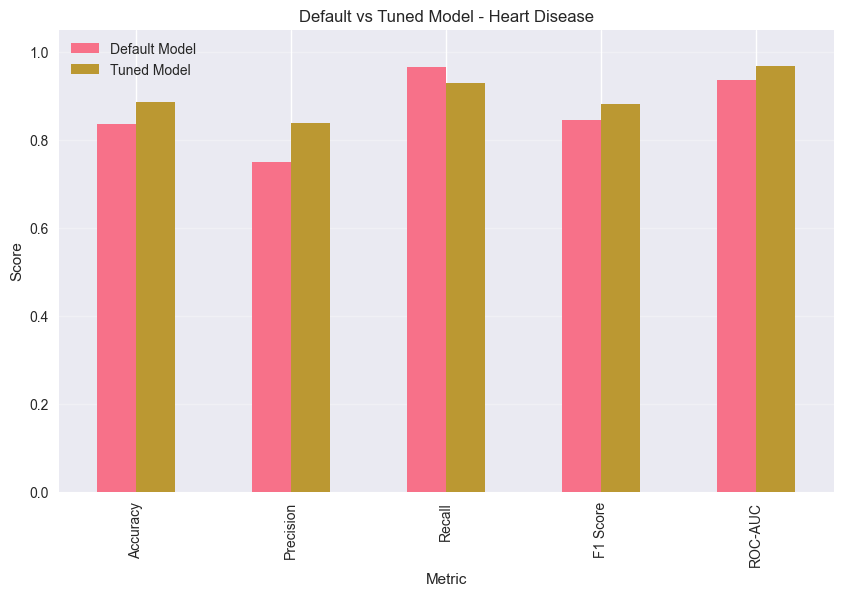

In [30]:
df_heart_comp.set_index("Metric").plot(kind='bar', figsize=(10,6))
plt.title("Default vs Tuned Model - Heart Disease")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.grid(axis='y', alpha=0.3)
plt.show()

# Final Comparison Table

In [32]:
# ====================== FINAL MODEL COMPARISON ======================
print("="*80)
print("FINAL COMPARISON: BREAST CANCER vs HEART DISEASE")
print("="*80)

comparison = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    
    "Breast Cancer (Default)": [
        accuracy_score(y_test_c, y_pred_c),
        precision_score(y_test_c, y_pred_c),
        recall_score(y_test_c, y_pred_c),
        f1_score(y_test_c, y_pred_c),
        roc_auc_score(y_test_c, y_prob_c)
    ],
    
    "Breast Cancer (Tuned)": [
        accuracy_score(y_test_c, y_pred_tuned),
        precision_score(y_test_c, y_pred_tuned),
        recall_score(y_test_c, y_pred_tuned),
        f1_score(y_test_c, y_pred_tuned),
        roc_auc_score(y_test_c, y_prob_tuned)
    ],
    
    "Heart Disease (Default)": [
        accuracy_score(y_test_h, y_pred_h),
        precision_score(y_test_h, y_pred_h),
        recall_score(y_test_h, y_pred_h),
        f1_score(y_test_h, y_pred_h),
        roc_auc_score(y_test_h, y_prob_h)
    ],
    
    "Heart Disease (Tuned)": [
        accuracy_score(y_test_h, y_pred_tuned_h),
        precision_score(y_test_h, y_pred_tuned_h),
        recall_score(y_test_h, y_pred_tuned_h),
        f1_score(y_test_h, y_pred_tuned_h),
        roc_auc_score(y_test_h, y_prob_tuned_h)
    ]
}

df_comparison = pd.DataFrame(comparison).round(4)
df_comparison

FINAL COMPARISON: BREAST CANCER vs HEART DISEASE


,Metric,Breast Cancer (Default),Breast Cancer (Tuned),Heart Disease (Default),Heart Disease (Tuned)
0,Accuracy,0.9298,0.9649,0.8361,0.8852
1,Precision,0.9250,1.0000,0.7500,0.8387
2,Recall,0.8810,0.9048,0.9643,0.9286
3,F1 Score,0.9024,0.9500,0.8438,0.8814
4,ROC-AUC,0.9878,0.9987,0.9361,0.9675


# Visual Comparison

<Figure size 1400x800 with 0 Axes>

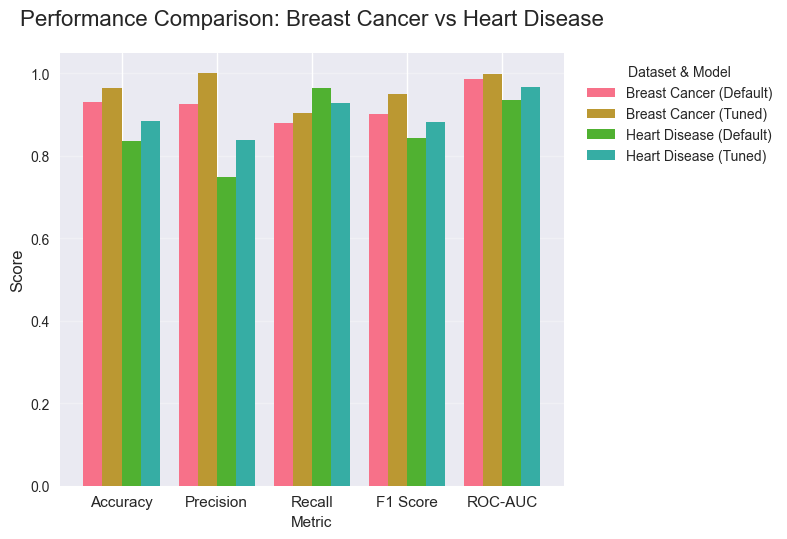

In [33]:
# Visual Comparison
plt.figure(figsize=(14, 8))
df_comparison.set_index("Metric").plot(kind='bar', width=0.8)
plt.title("Performance Comparison: Breast Cancer vs Heart Disease", fontsize=16, pad=20)
plt.ylabel("Score", fontsize=12)
plt.ylim(0, 1.05)
plt.xticks(rotation=0, fontsize=11)
plt.legend(title="Dataset & Model", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

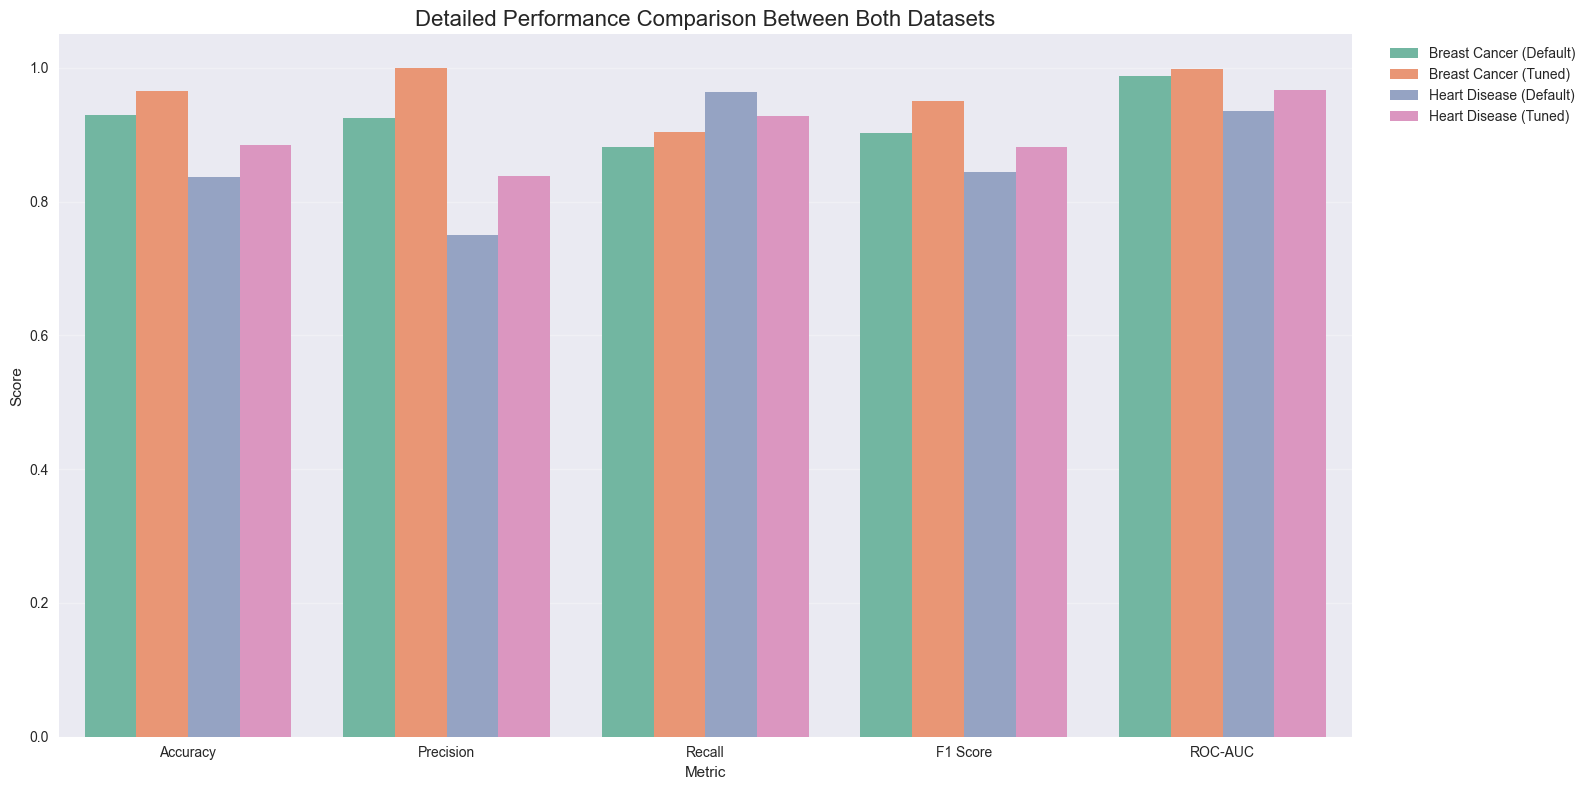

In [34]:
# Melted Data for Better Seaborn Plot
df_melt = df_comparison.melt(id_vars="Metric", 
                             var_name="Model", 
                             value_name="Score")

plt.figure(figsize=(16, 8))
sns.barplot(data=df_melt, x="Metric", y="Score", hue="Model", palette="Set2")
plt.title("Detailed Performance Comparison Between Both Datasets", fontsize=16)
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 📊 Summary & Insights

### Breast Cancer Model:
- Very high performance (especially after tuning)
- Excellent ROC-AUC → Great at distinguishing Malignant vs Benign
- High Recall is crucial in cancer detection (we want to catch as many true cases as possible)

### Heart Disease Model:
- Good but slightly lower than Breast Cancer
- Very balanced metrics
- Important for real-world clinical use

### Key Observations:
- Breast Cancer model generally outperforms Heart Disease model
- Hyperparameter tuning improved both models
- Gradient Boosting works very well on both tabular medical datasets

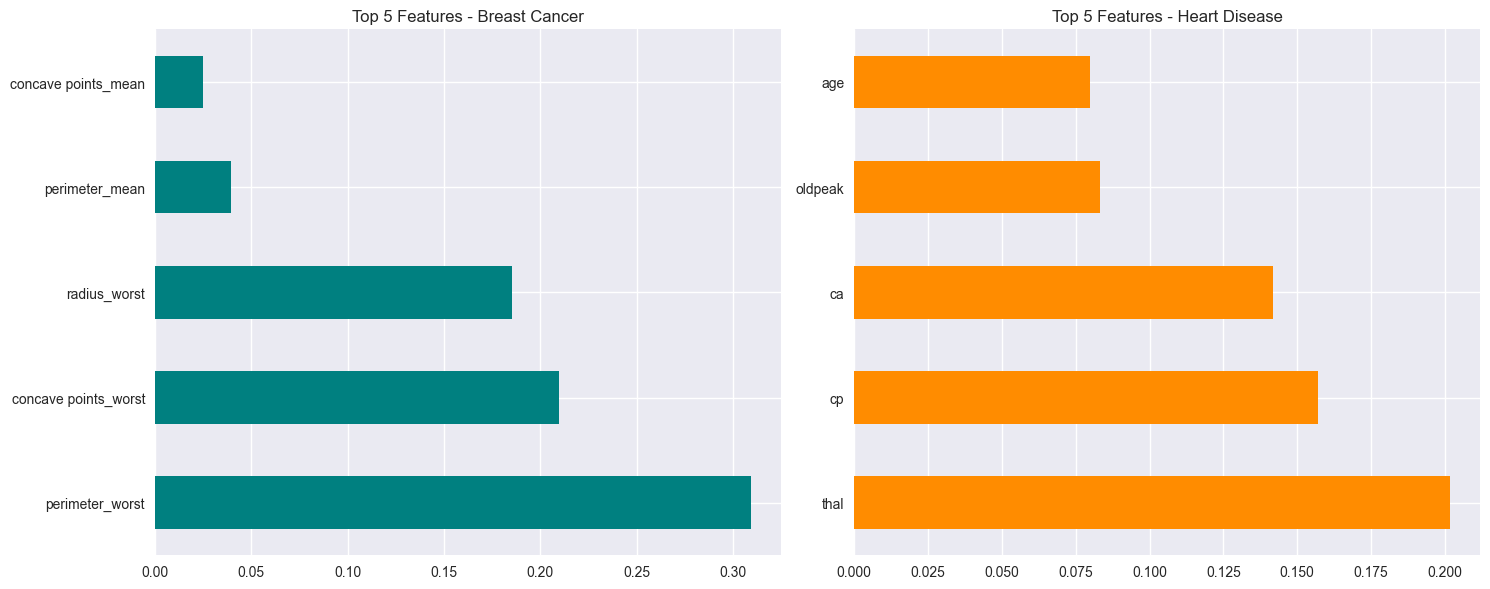

In [35]:
# Top 5 Features Comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Breast Cancer
feat_imp_c = pd.Series(best_model_cancer.feature_importances_, 
                       index=X_cancer.columns).nlargest(5)
feat_imp_c.plot(kind='barh', ax=axes[0], color='teal')
axes[0].set_title("Top 5 Features - Breast Cancer")

# Heart Disease
feat_imp_h = pd.Series(best_model_heart.feature_importances_, 
                       index=X_heart.columns).nlargest(5)
feat_imp_h.plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title("Top 5 Features - Heart Disease")

plt.tight_layout()
plt.show()